In [1]:
INPUT_PATH = "/kaggle/input/datasets/thuhiuhong/lstm-new-train-test-val-2"
MODEL_PATH = "/kaggle/input/models/thuhiuhong/lstm-multihorizon-model/keras/default/1/best_lstm_multihorizon_model.keras"

TOP_K_PATIENTS = 5   # số bệnh nhân top
BATCH_SIZE = 512

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K

print("TensorFlow version:", tf.__version__)

2026-04-08 17:40:49.201699: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775670049.482284      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775670049.550719      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775670050.177202      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775670050.177251      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775670050.177254      17 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [3]:
# ===== LOAD DATA =====
X_test = np.load(os.path.join(INPUT_PATH, "X_test.npy")).astype(np.float32)
y_test_sepsis6 = np.load(os.path.join(INPUT_PATH, "y_test_sepsis6.npy")).astype(np.float32)
id_test = np.load(os.path.join(INPUT_PATH, "id_test.npy"))

print("X_test shape:", X_test.shape)
print("y_test_sepsis6 shape:", y_test_sepsis6.shape)
print("id_test shape:", id_test.shape)

assert X_test.ndim == 3, "X_test phải có shape (N, seq_len, n_features)"
assert y_test_sepsis6.ndim == 2 and y_test_sepsis6.shape[1] == 6, "y_test_sepsis6 phải có shape (N, 6)"
assert len(X_test) == len(y_test_sepsis6) == len(id_test), "Số dòng giữa X_test, y_test_sepsis6, id_test phải khớp"

X_test shape: (37276, 10, 133)
y_test_sepsis6 shape: (37276, 6)
id_test shape: (37276,)


In [4]:
# ===== CUSTOM LOSS ĐỂ LOAD MODEL =====

flat_y = y_test_sepsis6.reshape(-1)
n_pos = np.sum(flat_y == 1)
n_neg = np.sum(flat_y == 0)
POS_WEIGHT = float(n_neg / max(n_pos, 1))

def weighted_bce_6(y_true, y_pred):
    eps = K.epsilon()
    y_pred = tf.clip_by_value(y_pred, eps, 1. - eps)
    loss = -(POS_WEIGHT * y_true * tf.math.log(y_pred) +
             (1. - y_true) * tf.math.log(1. - y_pred))
    return tf.reduce_mean(loss)

print("POS_WEIGHT =", POS_WEIGHT)

POS_WEIGHT = 14.383176284476237


In [5]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".keras") or f.endswith(".h5") or f == "saved_model.pb":
            print("FOUND:", os.path.join(root, f))

FOUND: /kaggle/input/models/thuhiuhong/lstm-multihorizon-model/keras/default/1/best_lstm_multihorizon_model.keras


In [6]:
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={"weighted_bce_6": weighted_bce_6}
)

model.summary()

2026-04-08 17:41:22.116385: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 133)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10, 32)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 16)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sepsis (Dense)                  │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,980 (261.64 KB)

 Trainable params: 22,294 (87.09 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 44,590 (174.18 KB)

In [7]:
# ===== PREDICT p_t1 ... p_t6 =====
pred_test = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)

print("pred_test shape:", pred_test.shape)
print("3 rows đầu:")
print(pred_test[:3])

assert pred_test.ndim == 2 and pred_test.shape[1] == 6, "Model phải output shape (N, 6)"

73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
pred_test shape: (37276, 6)
3 rows đầu:
[[0.0086168  0.00544777 0.00557696 0.00712352 0.00897245 0.00772707]
 [0.13417457 0.08175644 0.10983804 0.11089533 0.10473089 0.13443357]
 [0.00495951 0.00310721 0.00279972 0.00250274 0.00262131 0.00346053]]


In [8]:
# ===== TẠO BẢNG TRAJECTORY =====
traj_df = pd.DataFrame({
    "id": id_test,
    "true_t6": y_test_sepsis6[:, 5].astype(int),
    "p_t1": pred_test[:, 0],
    "p_t2": pred_test[:, 1],
    "p_t3": pred_test[:, 2],
    "p_t4": pred_test[:, 3],
    "p_t5": pred_test[:, 4],
    "p_t6": pred_test[:, 5],
})

traj_df["max_future_risk"] = traj_df[["p_t1","p_t2","p_t3","p_t4","p_t5","p_t6"]].max(axis=1)
traj_df["mean_future_risk"] = traj_df[["p_t1","p_t2","p_t3","p_t4","p_t5","p_t6"]].mean(axis=1)
traj_df["risk_slope"] = traj_df["p_t6"] - traj_df["p_t1"]

# Vì chưa có end_hour_test, dùng thứ tự sequence trong từng bệnh nhân
traj_df["seq_idx_in_patient"] = traj_df.groupby("id").cumcount()

traj_df = traj_df.sort_values(["id", "seq_idx_in_patient"]).reset_index(drop=True)
traj_df.head(10)

,id,true_t6,p_t1,p_t2,p_t3,p_t4,p_t5,p_t6,max_future_risk,mean_future_risk,risk_slope,seq_idx_in_patient
0,1,0,0.008617,0.005448,0.005577,0.007124,0.008972,0.007727,0.008972,0.007244,-0.000890,0
1,1,0,0.134175,0.081756,0.109838,0.110895,0.104731,0.134434,0.134434,0.112638,0.000259,1
2,4,0,0.004960,0.003107,0.002800,0.002503,0.002621,0.003461,0.004960,0.003242,-0.001499,0
3,4,0,0.013099,0.009087,0.009649,0.007637,0.008801,0.010894,0.013099,0.009861,-0.002205,1
4,4,0,0.018931,0.016761,0.018021,0.021019,0.024659,0.024922,0.024922,0.020719,0.005991,2
5,4,0,0.005592,0.002922,0.004176,0.004890,0.006149,0.005251,0.006149,0.004830,-0.000341,3
6,4,0,0.004265,0.002032,0.002945,0.003297,0.004310,0.004205,0.004310,0.003509,-0.000060,4
7,4,0,0.004978,0.002896,0.003124,0.003446,0.004242,0.006588,0.006588,0.004212,0.001610,5
8,7,0,0.008389,0.005913,0.005165,0.005732,0.005576,0.006829,0.008389,0.006267,-0.001560,0
9,7,0,0.383962,0.393910,0.386371,0.422517,0.361527,0.489390,0.489390,0.406280,0.105428,1


In [9]:
# ===== TÓM TẮT THEO BỆNH NHÂN =====
patient_summary = (
    traj_df.groupby("id")
    .agg(
        max_p_t6=("p_t6", "max"),
        max_future_risk=("max_future_risk", "max"),
        mean_future_risk=("mean_future_risk", "mean"),
        mean_slope=("risk_slope", "mean"),
        n_rows=("id", "size"),
        has_positive_t6=("true_t6", "max")
    )
    .reset_index()
)

patient_summary = patient_summary.sort_values(
    ["has_positive_t6", "max_future_risk", "mean_slope"],
    ascending=[False, False, False]
)

patient_summary.head(20)

,id,max_p_t6,max_future_risk,mean_future_risk,mean_slope,n_rows,has_positive_t6
2842,14886,0.950530,0.956234,0.832941,0.074115,41,1
2045,10644,0.948703,0.952670,0.718643,0.058738,45,1
1568,8034,0.945630,0.950964,0.801538,0.065954,40,1
2125,11104,0.945357,0.950422,0.757233,0.065872,33,1
1665,8489,0.943721,0.950106,0.853918,0.072532,51,1
282,1398,0.943903,0.949997,0.682831,0.053627,32,1
2443,12701,0.946328,0.949601,0.746555,0.059069,36,1
957,4900,0.942931,0.949521,0.770241,0.070958,13,1
1836,9392,0.946058,0.948108,0.618088,0.054295,21,1
210,1039,0.943526,0.947784,0.779857,0.065482,40,1


In [10]:
# ===== QUICK CHECK: tổng quan trajectory có khả quan không? =====
print("Số sequence:", len(traj_df))
print("Số bệnh nhân:", traj_df["id"].nunique())
print("Tỷ lệ sequence true_t6 = 1:", traj_df["true_t6"].mean().round(4))

print("\nSummary của p_t6:")
print(traj_df["p_t6"].describe())

print("\nSummary của max_future_risk:")
print(traj_df["max_future_risk"].describe())

print("\nSummary của risk_slope:")
print(traj_df["risk_slope"].describe())

# xem nhanh các bệnh nhân có trajectory "đáng chú ý"
print("\nTop bệnh nhân đáng xem:")
display(patient_summary.head(TOP_K_PATIENTS))

Số sequence: 37276
Số bệnh nhân: 7545
Tỷ lệ sequence true_t6 = 1: 0.075

Summary của p_t6:
count    37276.000000
mean         0.262970
std          0.318379
min          0.001437
25%          0.015036
50%          0.071280
75%          0.513748
max          0.950530
Name: p_t6, dtype: float64

Summary của max_future_risk:
count    37276.000000
mean         0.270051
std          0.320044
min          0.001572
25%          0.017780
50%          0.080197
75%          0.524076
max          0.956234
Name: max_future_risk, dtype: float64

Summary của risk_slope:
count    37276.000000
mean         0.032871
std          0.043816
min         -0.096731
25%         -0.001158
50%          0.007603
75%          0.076263
max          0.180821
Name: risk_slope, dtype: float64

Top bệnh nhân đáng xem:


,id,max_p_t6,max_future_risk,mean_future_risk,mean_slope,n_rows,has_positive_t6
2842,14886,0.950530,0.956234,0.832941,0.074115,41,1
2045,10644,0.948703,0.952670,0.718643,0.058738,45,1
1568,8034,0.945630,0.950964,0.801538,0.065954,40,1
2125,11104,0.945357,0.950422,0.757233,0.065872,33,1
1665,8489,0.943721,0.950106,0.853918,0.072532,51,1


In [11]:
# ===== HÀM VẼ SUMMARY =====
def plot_patient_risk_summary(traj_df, patient_id):
    df = traj_df[traj_df["id"] == patient_id].copy().sort_values("seq_idx_in_patient")

    if len(df) == 0:
        print("Không tìm thấy patient_id")
        return

    plt.figure(figsize=(10, 5))
    plt.plot(df["seq_idx_in_patient"], df["p_t6"], label="p_t6")
    plt.plot(df["seq_idx_in_patient"], df["max_future_risk"], label="max_future_risk")
    plt.plot(df["seq_idx_in_patient"], df["mean_future_risk"], label="mean_future_risk")

    plt.title(f"Risk trajectory summary - patient {patient_id}")
    plt.xlabel("Sequence order within patient")
    plt.ylabel("Risk")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()

In [12]:
# ===== HÀM VẼ ĐỦ 6 HORIZON =====
def plot_patient_all_horizons(traj_df, patient_id):
    df = traj_df[traj_df["id"] == patient_id].copy().sort_values("seq_idx_in_patient")

    if len(df) == 0:
        print("Không tìm thấy patient_id")
        return

    plt.figure(figsize=(12, 6))
    for col in ["p_t1", "p_t2", "p_t3", "p_t4", "p_t5", "p_t6"]:
        plt.plot(df["seq_idx_in_patient"], df[col], label=col)

    plt.title(f"All multi-horizon risks - patient {patient_id}")
    plt.xlabel("Sequence order within patient")
    plt.ylabel("Predicted risk")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend(ncol=2)
    plt.show()

In [13]:
# ===== HÀM VẼ KÈM ALERT =====
def plot_patient_with_alerts(traj_df, patient_id, threshold=0.17):
    df = traj_df[traj_df["id"] == patient_id].copy().sort_values("seq_idx_in_patient")

    if len(df) == 0:
        print("Không tìm thấy patient_id")
        return

    plt.figure(figsize=(10, 5))
    plt.plot(df["seq_idx_in_patient"], df["p_t6"], label="p_t6")
    plt.plot(df["seq_idx_in_patient"], df["max_future_risk"], label="max_future_risk")

    alert_df = df[df["p_t6"] >= threshold]
    if len(alert_df) > 0:
        plt.scatter(alert_df["seq_idx_in_patient"], alert_df["p_t6"], label="alert points")

    pos_df = df[df["true_t6"] == 1]
    if len(pos_df) > 0:
        for x in pos_df["seq_idx_in_patient"]:
            plt.axvline(x, linestyle="--", alpha=0.4)

    plt.title(f"Risk trajectory with alerts - patient {patient_id}")
    plt.xlabel("Sequence order within patient")
    plt.ylabel("Risk")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()

In [14]:
# ===== CHỌN NHANH VÀI BỆNH NHÂN ĐỂ XEM =====
selected_patients = patient_summary["id"].head(TOP_K_PATIENTS).tolist()
selected_patients

[14886, 10644, 8034, 11104, 8489]

PATIENT: 14886


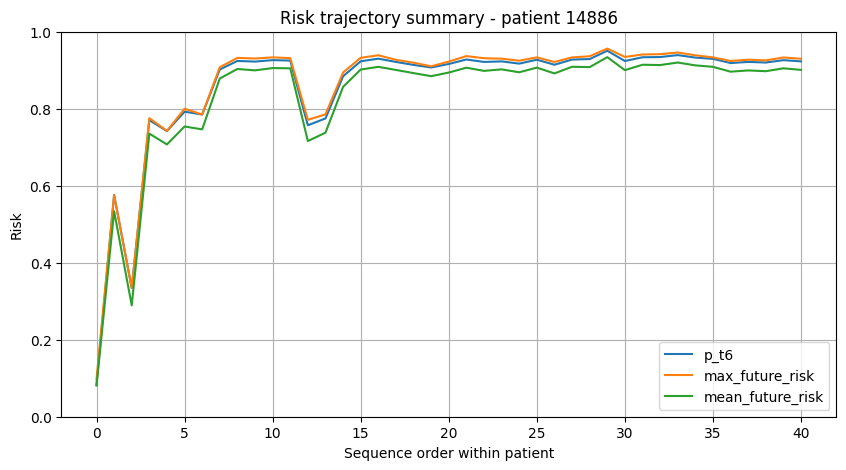

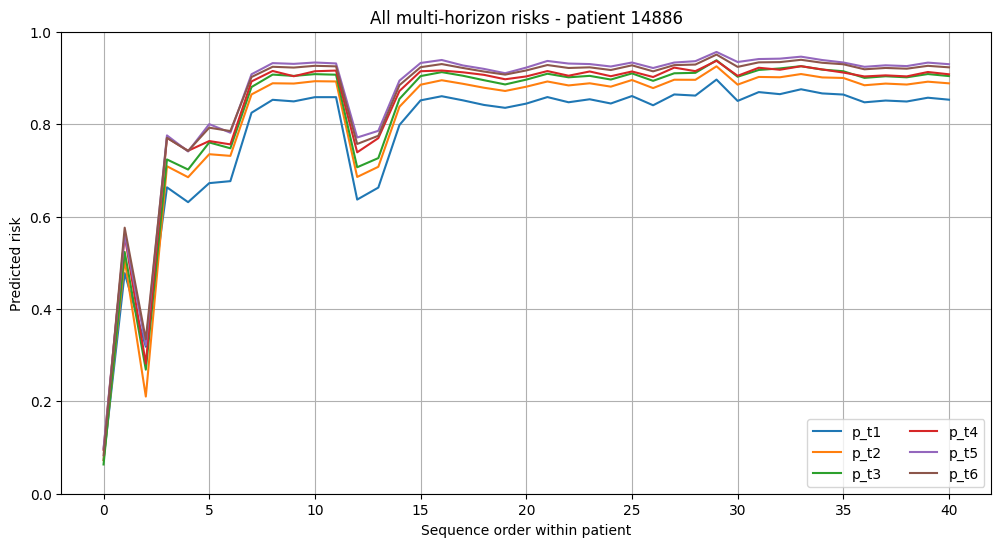

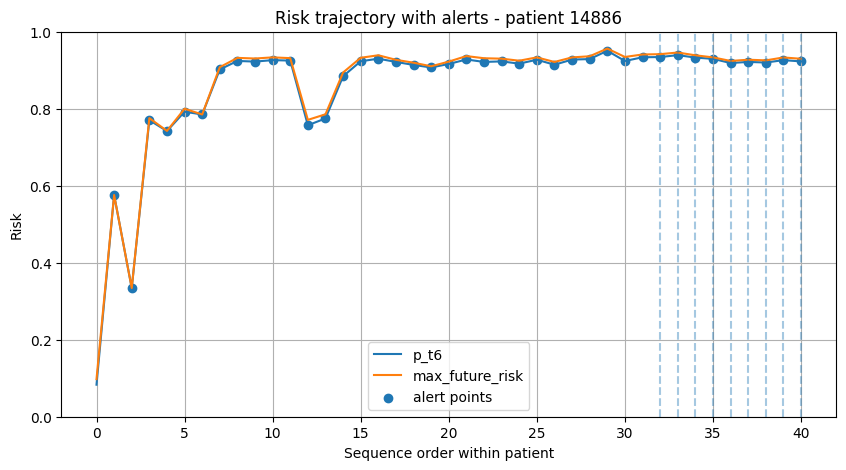

PATIENT: 10644


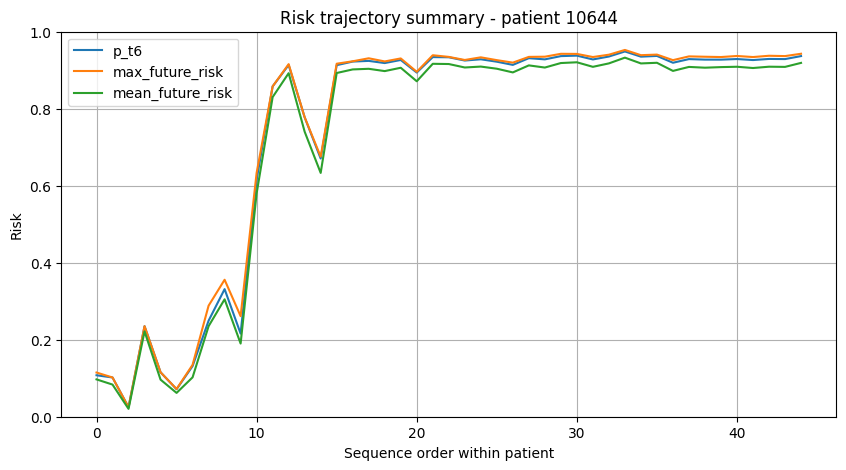

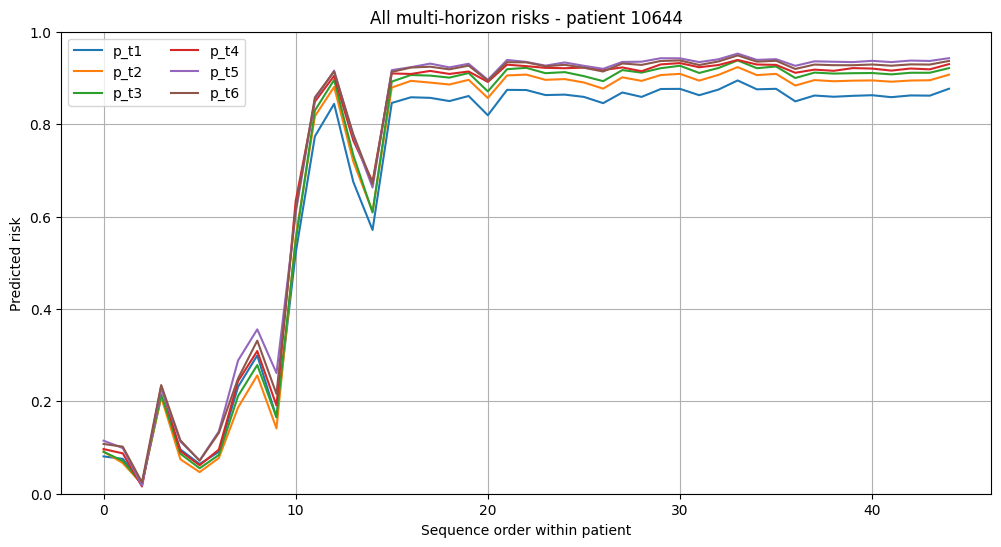

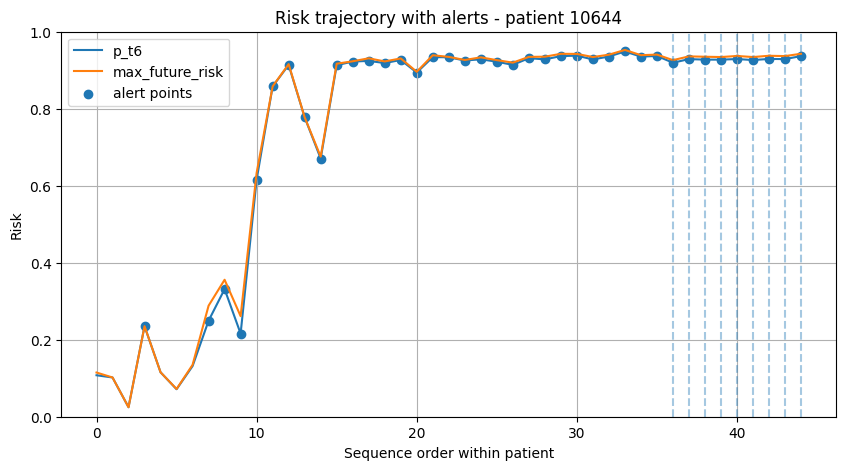

PATIENT: 8034


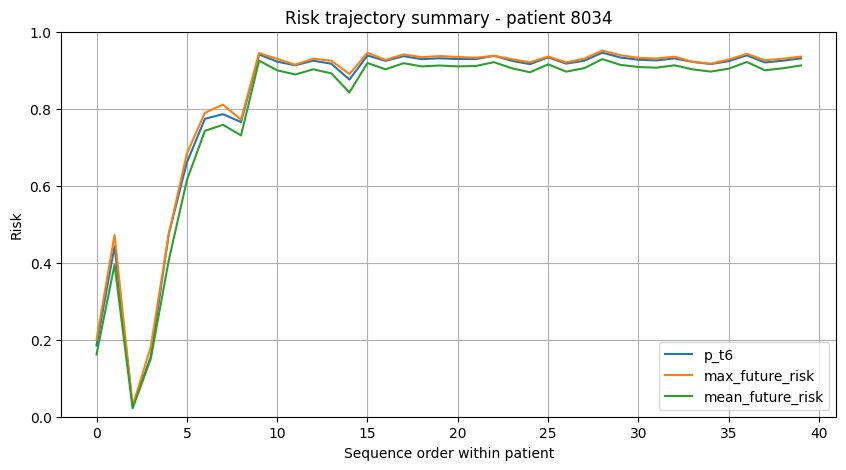

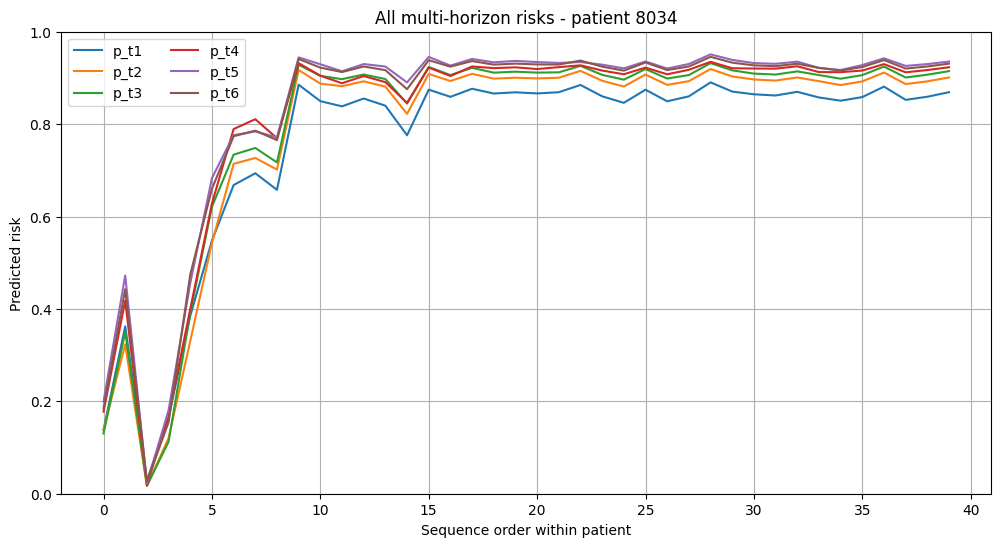

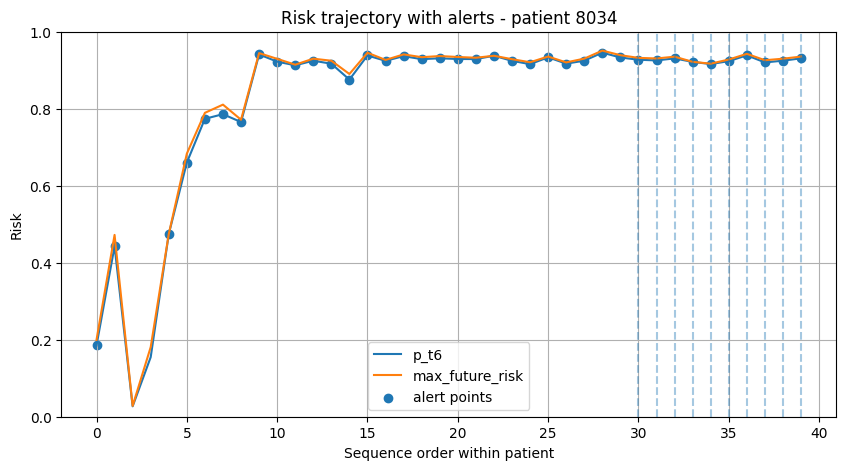

PATIENT: 11104


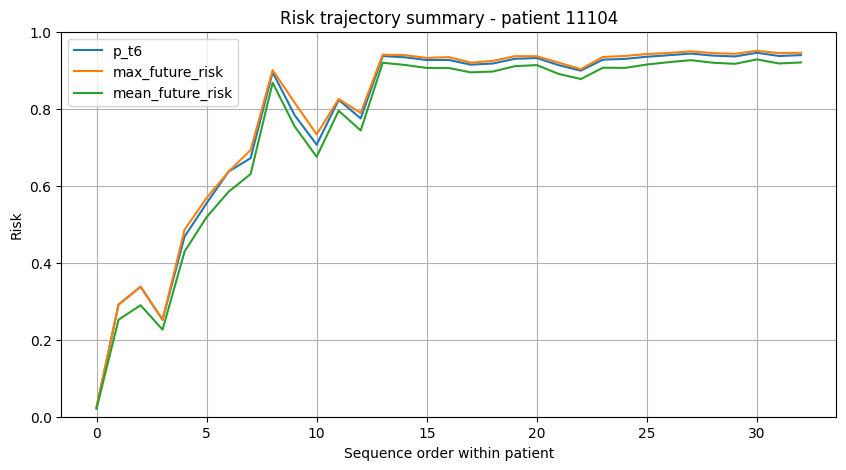

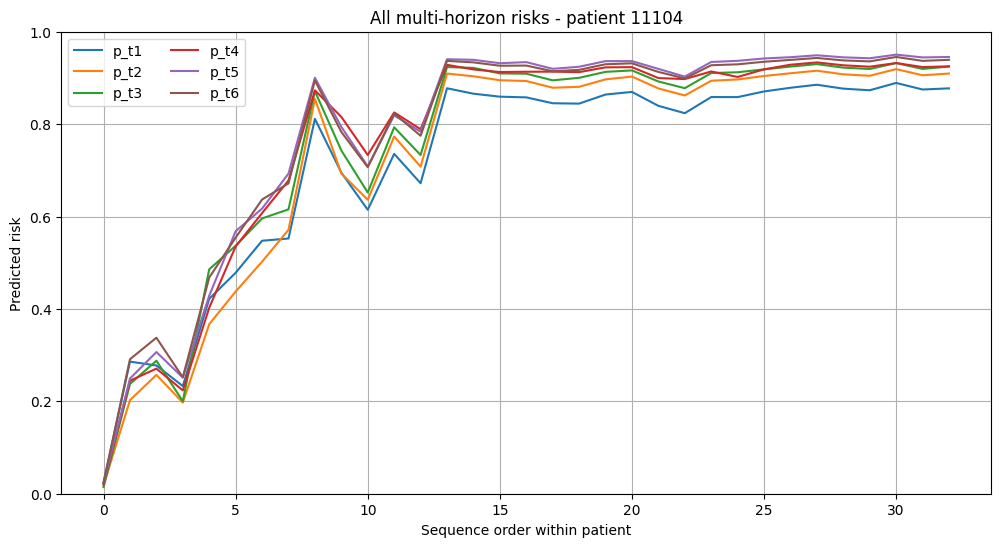

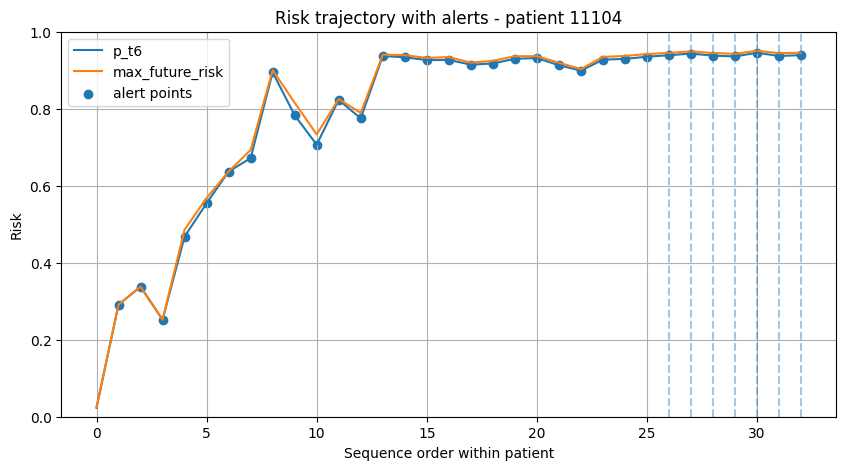

PATIENT: 8489


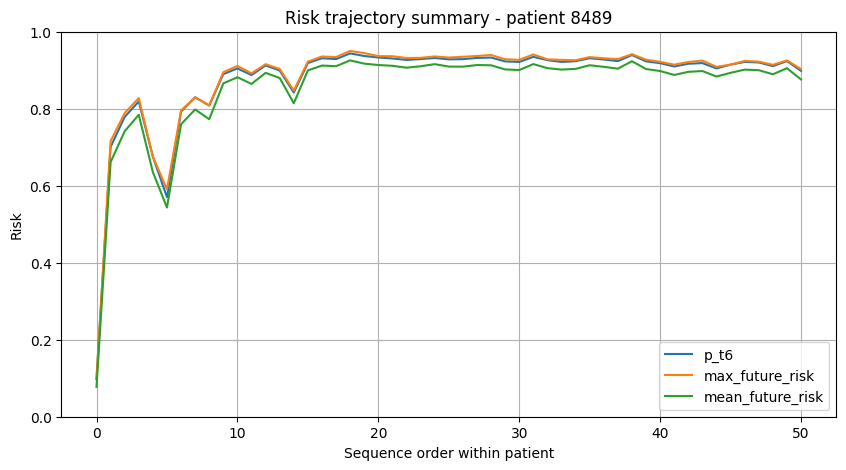

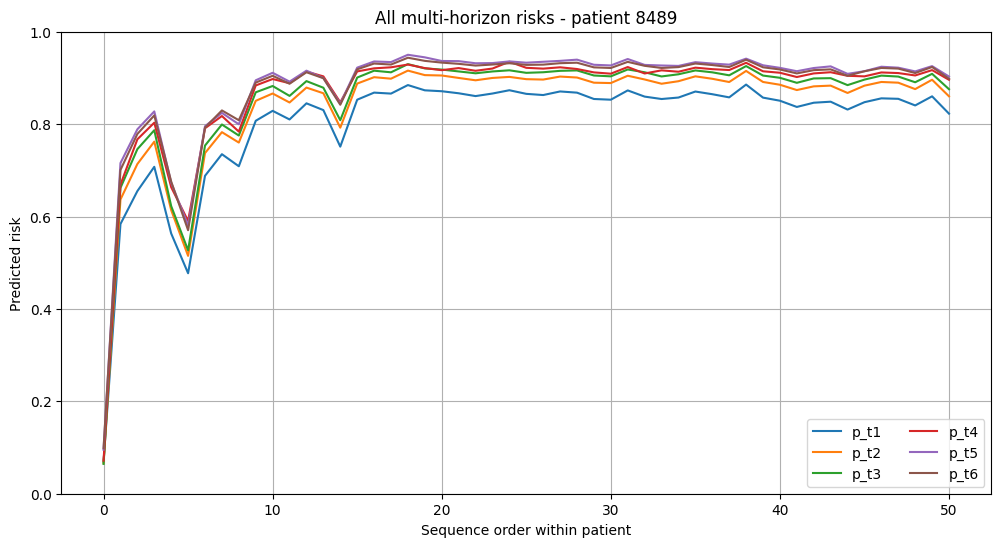

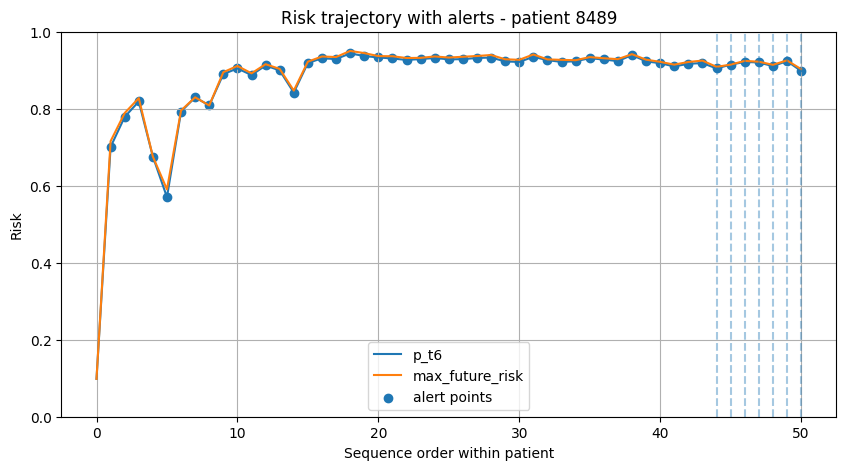

In [15]:
# ===== VẼ NHANH TOP PATIENTS =====
for pid in selected_patients:
    print("=" * 100)
    print("PATIENT:", pid)
    plot_patient_risk_summary(traj_df, pid)
    plot_patient_all_horizons(traj_df, pid)
    plot_patient_with_alerts(traj_df, pid, threshold=0.17)

In [16]:
# ===== CHỌN 1 BỆNH NHÂN =====
# Ví dụ:
# manual_pid = selected_patients[0]
# plot_patient_risk_summary(traj_df, manual_pid)
# plot_patient_all_horizons(traj_df, manual_pid)
# plot_patient_with_alerts(traj_df, manual_pid, threshold=0.17)

In [17]:
# ===== XUẤT CSV =====
traj_df.to_csv("/kaggle/working/risk_trajectory_test_seq_order.csv", index=False)
patient_summary.to_csv("/kaggle/working/risk_trajectory_patient_summary.csv", index=False)

print("Đã lưu:")
print("- /kaggle/working/risk_trajectory_test_seq_order.csv")
print("- /kaggle/working/risk_trajectory_patient_summary.csv")

Đã lưu:
- /kaggle/working/risk_trajectory_test_seq_order.csv
- /kaggle/working/risk_trajectory_patient_summary.csv
